# 🏠 House Price Prediction using Machine Learning

## Project Overview
This project aims to predict house prices using machine learning techniques based on various property features such as area, number of bedrooms, bathrooms, location, and other relevant factors. The objective is to build a regression model that can accurately estimate house prices and help buyers, sellers, and real estate businesses make data-driven decisions.

## Project Workflow
- Import Libraries
- Load Dataset
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Train-Test Split
- Model Building
- Model Evaluation
- Hyperparameter Tuning
- Final Prediction

## Technologies Used
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

## Objective
The main goal of this project is to analyze housing data, identify the factors affecting house prices, and develop a machine learning model that provides reliable price predictions based on input features.

In [367]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [368]:
# load the data
data = pd.read_csv(r"C:\\Users\\seema jangir\\Downloads\\archive (4).zip")

In [369]:
data # overview the data

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0
...,...,...,...,...,...,...,...,...,...
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0


1.Overview the data


In [370]:
data.shape # the shape of data look like 

(1124, 9)

In [371]:
data.size # size of the data

10116

In [372]:
# overview the data at top.
data.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [373]:
# overview the data from bottom.
data.tail()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
1119,2461.048417,7.0,1988,Noida,Corner Plot,Unfurnished,Duplex,No,699925.0
1120,3558.174078,7.0,1989,Kanpur,Highway Facing,Unfurnished,Apartment,No,736329.0
1121,2179.880978,4.0,2011,Prayagraj,Residential Lane,Semi-Furnished,Duplex,No,533498.0
1122,NaN,6.0,2022,Delhi,Main Road,Unfurnished,Independent House,No,533436.0
1123,3022.318426,4.0,2011,Gurugram,Residential Lane,Unfurnished,Independent House,Yes,780760.0


In [374]:
# information about the data.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   str    
 4   Street_Type    1124 non-null   str    
 5   Furnishing     1091 non-null   str    
 6   Property_Type  1124 non-null   str    
 7   Has_Pool       1124 non-null   str    
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 79.2 KB


In [375]:
data['Price'].max()

np.float64(2071401.84)

2.Statistical Analysis

In [376]:
# Statistical Analysis of data using the describe method.
data.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1091.000000,1091.000000,1124.000000,1.124000e+03
mean,2237.479473,4.568286,2005.080071,6.082015e+05
std,731.097828,1.678155,11.708876,1.431958e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1834.022964,3.000000,1995.000000,5.161948e+05
50%,2201.545784,5.000000,2005.000000,6.025410e+05
75%,2576.139355,6.000000,2015.000000,6.895785e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


According to Statistical Analysis   
1.The minimum price of the house is 248640 and the maximun price is 2071401.84   
2.The minimum requrement of the room as per the data is 2    
3.As increasing the area the price,room etc are also increase .

3. Graphical Representation of Statistical Analysis

<Axes: >

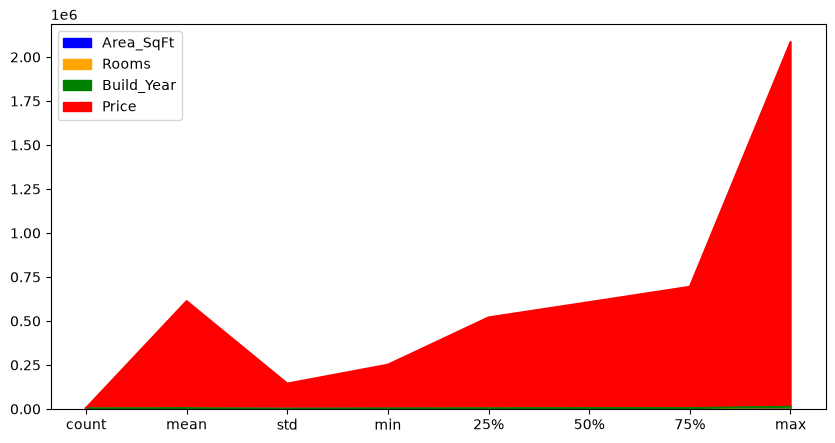

In [377]:
data.describe().plot(kind= 'area',stacked='False',figsize=(10,5),color=['Blue','Orange','Green','red'])

4. Data Cleaning

In [378]:
# data have any missing value.
data.isna().sum()

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

In [379]:
# data have any duplicate value
data.duplicated().sum()

np.int64(0)

According to our data there some missing value so first with the help of imputer fill it 

In [380]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy='mean')
data[['Area_SqFt']] = si.fit_transform(data[['Area_SqFt']]) # using the simple imputer fill Area_SqFt column by mean

# similarly fill room column
data[['Rooms']] = si.fit_transform(data[['Rooms']])

# for categoryical column 
si = SimpleImputer(strategy='most_frequent')
data[['Furnishing']] = si.fit_transform(data[['Furnishing']])

In [381]:
# checking the data that have any missing value.
data.isna().sum()

Area_SqFt        0
Rooms            0
Build_Year       0
Location         0
Street_Type      0
Furnishing       0
Property_Type    0
Has_Pool         0
Price            0
dtype: int64

5. Exploratory Data Analysis (EDA)

Univariate Analysis

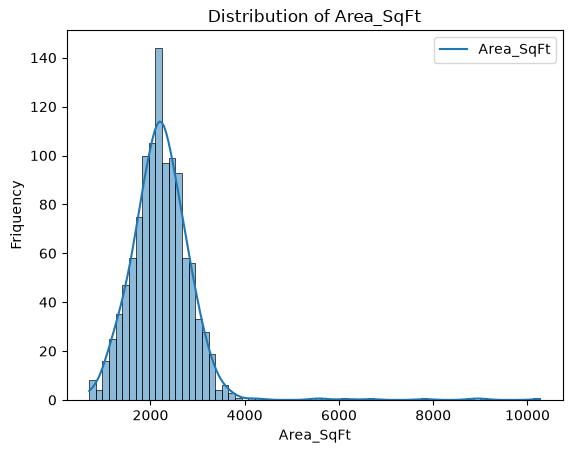

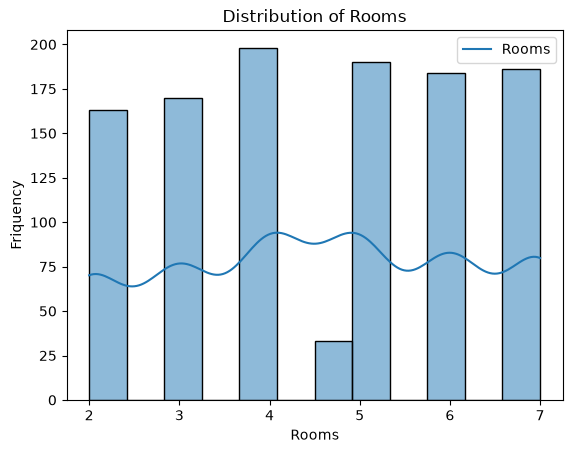

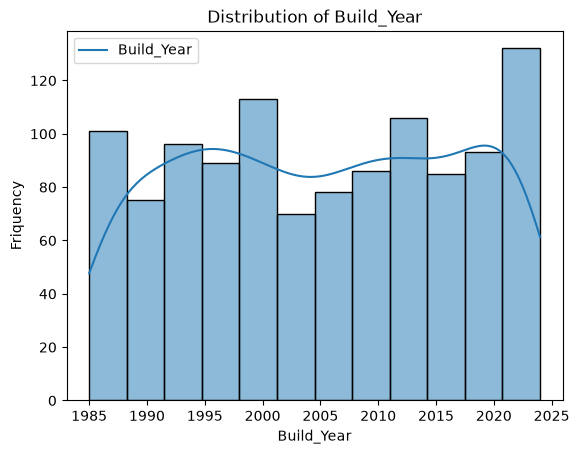

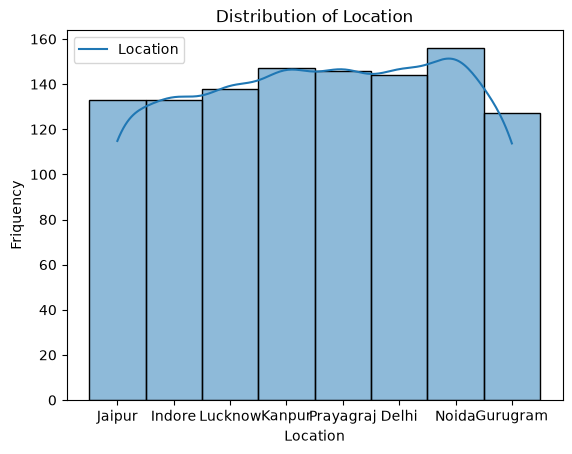

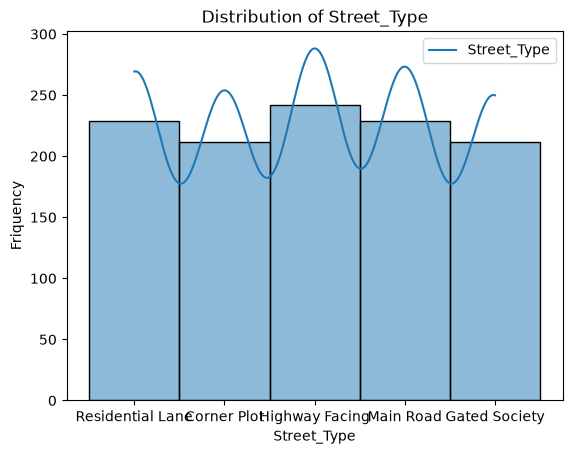

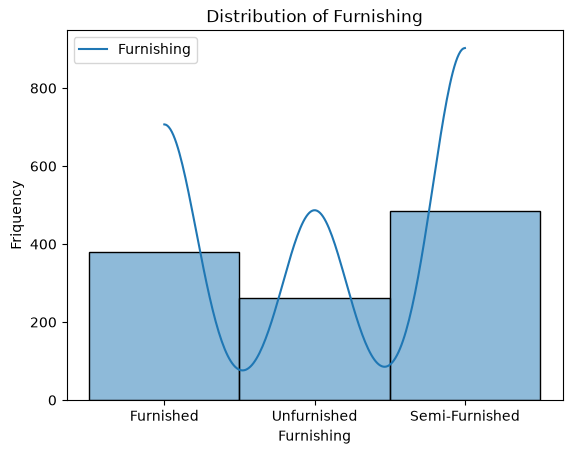

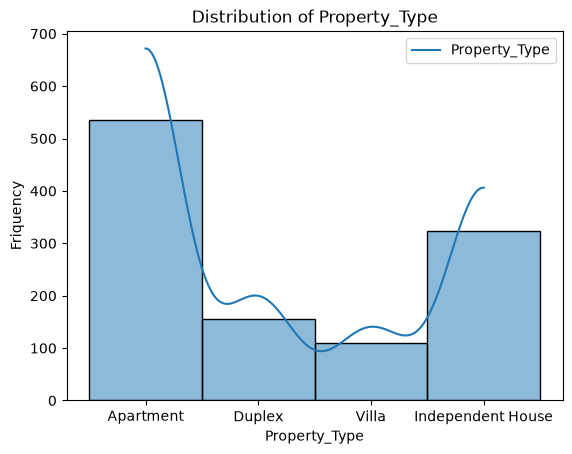

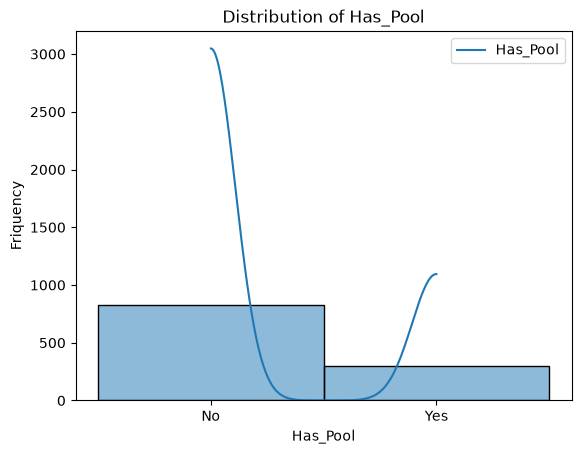

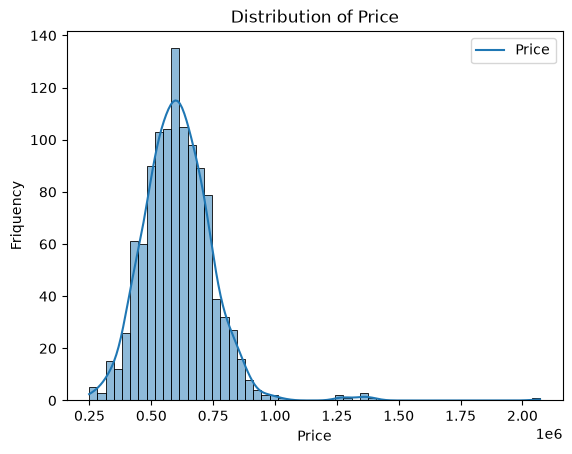

Area_SqFt
Mean   : 2237.48
Median   : 2219.01
Min   : 700.00
Max   : 10267.12
Rooms
Mean   : 4.57
Median   : 4.57
Min   : 2.00
Max   : 7.00
Build_Year
Mean   : 2005.08
Median   : 2005.00
Min   : 1985.00
Max   : 2024.00
Price
Mean   : 608201.51
Median   : 602541.00
Min   : 248640.00
Max   : 2071401.84


In [382]:
for col in data:
  sns.histplot(data[col],kde=True)
  plt.xlabel(f'{col}')
  plt.ylabel('Friquency')
  plt.title(f'Distribution of {col}')
  plt.legend(labels = {col})
  plt.show()

for col in data.select_dtypes(include='number').columns:
  print(f"{col}")
  print(f"Mean   : {data[col].mean():.2f}")
  
  print(f"Median   : {data[col].median():.2f}")
  print(f"Min   : {data[col].min():.2f}")
  print(f"Max   : {data[col].max():.2f}")


Bivariate Analysis

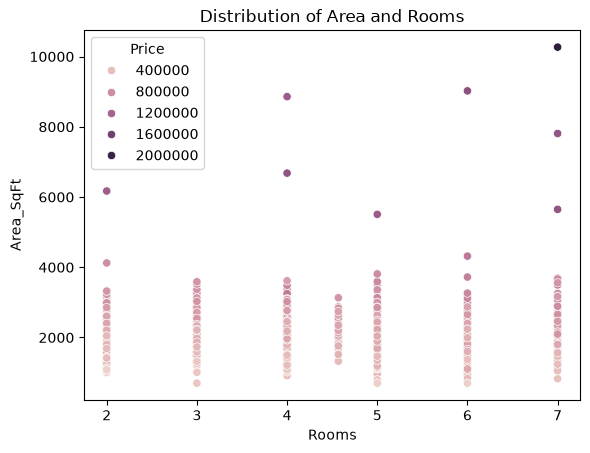

In [383]:
plt.Figure(figsize=(12,6))
sns.scatterplot(y = 'Area_SqFt',x = 'Rooms',data = data,hue = 'Price')
plt.ylabel("Area_SqFt")
plt.xlabel('Rooms')
plt.title("Distribution of Area and Rooms")

plt.show()

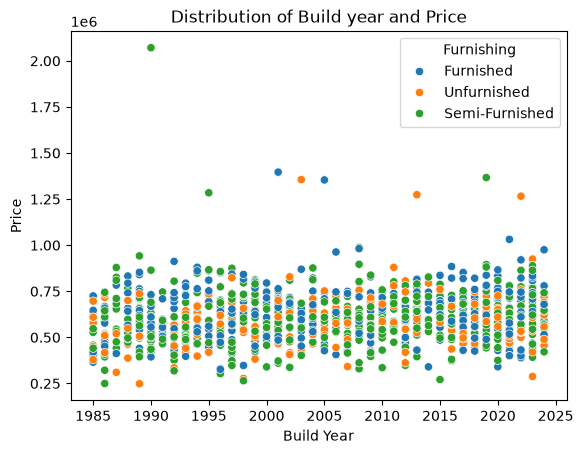

In [384]:
plt.Figure(figsize=(12,6))
sns.scatterplot(y = 'Price',x = 'Build_Year',data = data,hue = 'Furnishing')
plt.ylabel("Price")
plt.xlabel('Build Year')
plt.title("Distribution of Build year and Price")

plt.show()

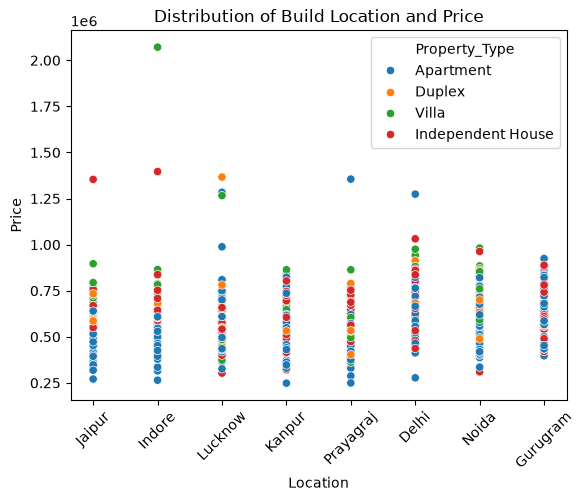

In [385]:
plt.Figure(figsize=(12,6))
sns.scatterplot(y = 'Price',x = 'Location',data = data,hue = 'Property_Type')
plt.ylabel("Price")
plt.xlabel('Location')
plt.xticks(rotation = 45)
plt.title("Distribution of Build Location and Price")

plt.show()

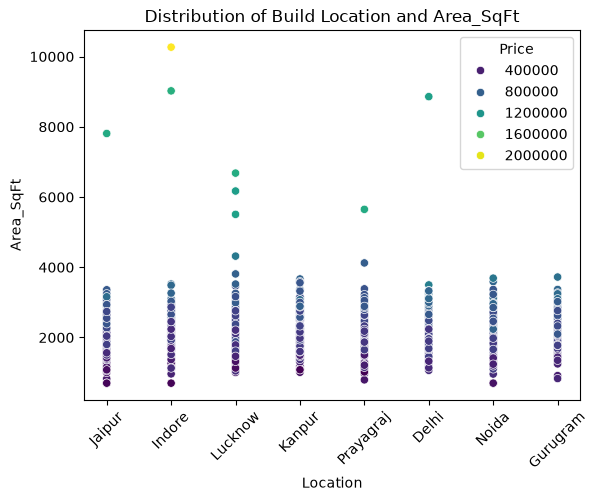

In [386]:
plt.Figure(figsize=(12,6))
sns.scatterplot(y = 'Area_SqFt',x = 'Location',data = data,hue = 'Price',palette='viridis')
plt.ylabel("Area_SqFt")
plt.xlabel('Location')
plt.xticks(rotation = 45)
plt.title("Distribution of Build Location and Area_SqFt")

plt.show()

As per the above analysis 
1. There are some Outliers in the data  
2. As per the analysis the there will be good correlation with price 
3. Location , Area etc are good relation  
4. As per analysis The target column is Price  


Before finding the relation first convert all string column into int. column with the help of label encoder or one hot encoder


In [387]:
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
data['Furnishing'] = LE.fit_transform(data['Furnishing'])
data['Has_Pool'] = LE.fit_transform(data['Has_Pool'])
data['Location'] = LE.fit_transform(data['Location'])
data['Property_Type'] = LE.fit_transform(data['Property_Type'])
data['Street_Type'] = LE.fit_transform(data['Street_Type'])

In [388]:
data.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,3,4,0,0,0,568486.0
1,2353.472711,4.0,2006,2,0,2,0,1,577214.0
2,2212.222005,3.0,2012,3,2,1,1,0,581300.0
3,2823.886596,6.0,1993,5,3,2,3,1,794614.0
4,1869.648721,5.0,2012,3,0,1,0,0,493086.0


Correlation graph

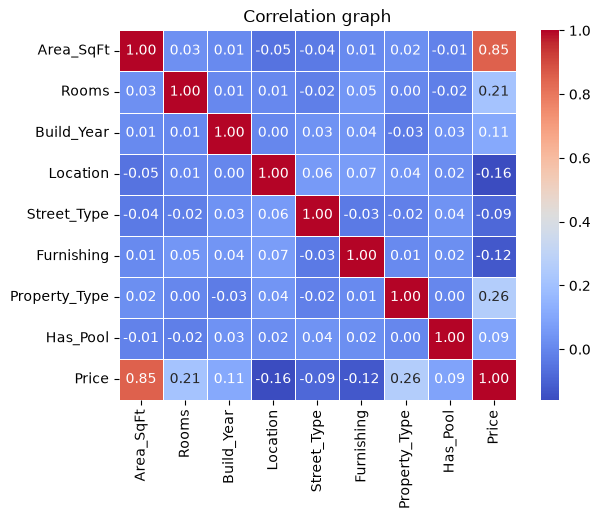

In [389]:
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation graph")
plt.show()

From above graph the price have good relation with area, rooms, Building year , Property type,Has pool have positive relation 

Feature Engineering

find Outliers


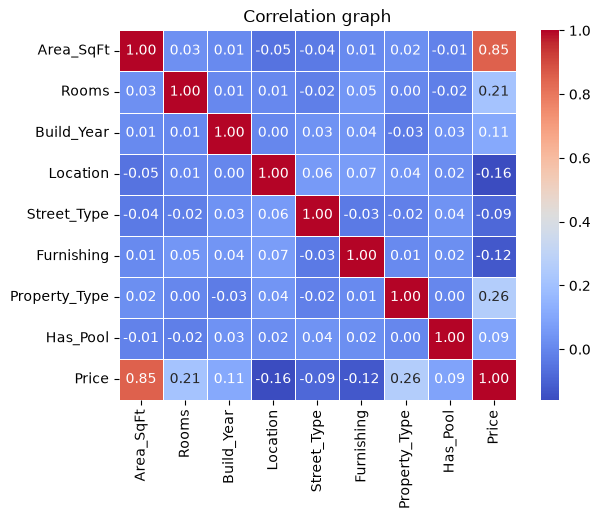

In [390]:
corr = data.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation graph")
plt.show()

In [391]:
#df = data[['Area_SqFt','Rooms','Build_Year','Property_Type','Price']]

In [392]:
#df.shape

6. Train Test Split

In [393]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
X = data.drop('Price',axis=1)
y = data['Price']
 
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scale = RobustScaler()
X_train = scale.fit_transform(X_train)

X_test =  scale.transform(X_test)

As per the target column is not problem of classifier it would be Regressor problem so we use different model 

1.Random forest

In [394]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,r2_score
model = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=1,max_depth=10,min_samples_leaf=1,min_samples_split=2)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)

In [395]:
print(r2)

0.9134749010246993


2.KNN

In [396]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor(n_neighbors=7)
kn.fit(X_train,y_train)
y_pred = kn.predict(X_test)
r2_ = r2_score(y_test,y_pred)
 

In [397]:
print(r2_)

0.8219631139175994


3.Decision Tree

In [398]:
from sklearn.tree import DecisionTreeRegressor
DE = DecisionTreeRegressor(random_state=2,max_depth=100)
DE.fit(X_train,y_train)

ypred = DE.predict(X_test)

r2score = r2_score(y_test,ypred)

In [399]:
print(r2score)

0.7925596237009318


In [400]:
print("Train R2:", model.score(X_train, y_train))
print("Test R2:", model.score(X_test, y_test))

Train R2: 0.9737259361797228
Test R2: 0.9134749010246993


In [401]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 50309.167641904765
MSE: 3762434124.046761
RMSE: 61338.68374889341


R² = 0.9136 means your model explains 91.36% of the variation in house prices.   
✅ MAE = 33,886.70 means the predicted house price differs from the actual price by about 33.9k on average.    
✅ RMSE = 42,728.97 is slightly higher than MAE, indicating that a few predictions have larger errors, which is common in house price datasets.

4.Gradint Booster


In [402]:
from sklearn.ensemble import GradientBoostingRegressor
GRB = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1,random_state=25)

GRB.fit(X_train,y_train)
ypd = GRB.predict(X_test)
score = r2_score(y_test,ypd)

In [403]:
print(score)

0.9444544559095228


In [404]:
print("Train R2:", GRB.score(X_train, y_train))
print("Test R2:", GRB.score(X_test, y_test))

Train R2: 0.9643837764190228
Test R2: 0.9444544559095228


5.XGBoost


In [405]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.111,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

score1 = r2_score(y_test,y_pred)

In [406]:
print(score1)

0.9187576069305348


In [407]:
print("Train R2:", xgb.score(X_train, y_train))
print("Test R2:", xgb.score(X_test, y_test))

Train R2: 0.993620514465754
Test R2: 0.9187576069305348


6.Cat boost

In [408]:
from catboost import CatBoostRegressor

CBR = CatBoostRegressor(n_estimators=1000,random_state=5,learning_rate=0.05,verbose=0,max_depth=2)

CBR.fit(X_train,y_train)

ypd = CBR.predict(X_test)

score2 = r2_score(y_test,ypd)

print(score2)

0.9667320153632883


In [409]:
print("Train R2:", CBR.score(X_train, y_train))
print("Test R2:", CBR.score(X_test, y_test))

Train R2: 0.9655330735166169
Test R2: 0.9667320153632883


# ploting the Feature



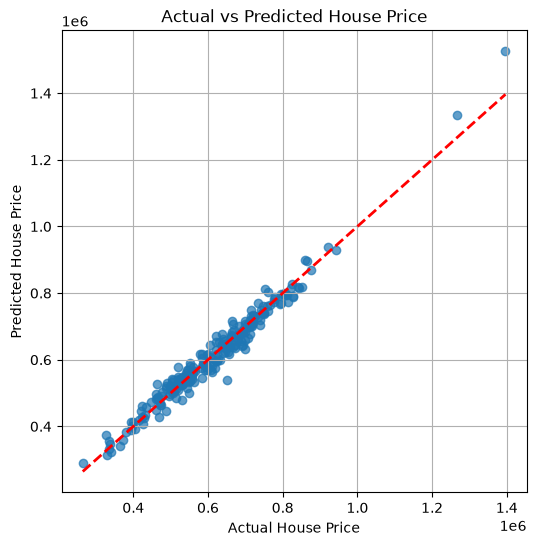

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, ypd, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")
plt.grid(True)
plt.show()

🏆 Final Results    
Model	Test R²         
KNN	0.72         
Decision Tree	0.79         
Random Forest	0.9136        
XGBoost	0.91            
Gradient Boosting	0.9445          
CatBoost	0.9667 ⭐           
📌 Final Conclusion          

"After evaluating multiple machine learning algorithms, CatBoost Regressor achieved the highest Test R² score of 96.67% with excellent generalization performance. Therefore, it was selected as the final model for house price prediction."  



Save the model


In [413]:
import joblib

joblib.dump(CBR,'catboost_model.pkl')

['catboost_model.pkl']

In [414]:
joblib.dump(scale,'robust_scaler.pkl')

['robust_scaler.pkl']